# Build an LSTM Model for One Ticker

This notebook trains the LSTM return-regression model on one ticker first. It uses a 30-day input window and predicts the 5-trading-day return after the prediction date.

The single-ticker run is a fast check before training the same model across sectors.

In [41]:
# Run this install cell only when the notebook environment is missing packages.
# %pip install tensorflow scikit-learn matplotlib pandas yfinance ta

In [42]:
# Keep the imports together so the notebook dependencies are easy to check.
import re
import sys
from pathlib import Path

# Add the backend folder to the path so this notebook can reuse the shared project code.
sys.path.insert(0, "..")

import matplotlib.pyplot as plt
import numpy as np
import pandas as pd

# Use the same feature function as the baseline notebook.
from core.fetch_data import SELECTED_FEATURE_COLS, get_ticker_features
from sklearn.metrics import (
    mean_absolute_error,
    mean_absolute_percentage_error,
    mean_squared_error,
)
from sklearn.preprocessing import MinMaxScaler
from tensorflow import keras
from tensorflow.keras import layers

## 1. Configuration

In [43]:
# Start the raw feature download before the model period.
# This gives the moving averages enough warm-up data before 2022.
FEATURE_START = "2021-10-01"

# Keep the train, validation, and test periods separate by date.
# This makes the test period a clean final check on 2025 data.
TRAIN_START = "2022-01-01"
TRAIN_MODEL_END = "2023-12-31"
VALIDATION_START = "2024-01-01"
VALIDATION_END = "2024-12-31"
TEST_START = "2025-01-01"
TEST_END = "2025-12-31"

# Download past 2025 because a late-2025 row still needs 5 future trading days.
DOWNLOAD_END = "2026-01-10"

# Use a 30-day input window to predict the 5-trading-day return.
FORECAST_HORIZON = 5
WINDOW_SIZE = 30

# These settings control the model training loop.
MAX_EPOCHS = 30
BATCH_SIZE = 128
EARLY_STOPPING_PATIENCE = 5
RANDOM_SEED = 42

# Save the single-ticker model to a separate folder.
MODEL_DIR = Path("../trained_models/lstm_single_ticker_return_regression")
MODEL_DIR.mkdir(parents=True, exist_ok=True)

# Use the shared feature list from fetch_data.py and remove duplicates defensively.
FEATURE_COLS = list(dict.fromkeys(SELECTED_FEATURE_COLS))
SINGLE_TICKER = "AAPL"

print(f"{len(FEATURE_COLS)} features per day, {WINDOW_SIZE}-day sequences")
print(f"Forecast target: {FORECAST_HORIZON}-trading-day return")
print(f"Single ticker test: {SINGLE_TICKER}")

18 features per day, 30-day sequences
Forecast target: 5-trading-day return
Single ticker test: AAPL


## 2. Load Single Ticker Features

In [44]:
# Calculate the features once so the same source data is used throughout the notebook.
ticker_features = {}

df = get_ticker_features(
    ticker=SINGLE_TICKER,
    start=FEATURE_START,
    end=DOWNLOAD_END,
    smooth_outliers=True,
)

# Skip tickers that cannot create one complete sequence and one future target.
required_rows = WINDOW_SIZE + FORECAST_HORIZON + 1
if df.empty or len(df) < required_rows:
    raise ValueError(f"{SINGLE_TICKER}: only {len(df)} rows are available")

ticker_features[SINGLE_TICKER] = df
print(
    f"{SINGLE_TICKER}: {len(df)} rows ({df.index[0].date()} to {df.index[-1].date()})"
)

AAPL: 1024 rows (2021-12-10 to 2026-01-09)


## 3. Build Training Datasets

In [45]:
# These helpers turn each ticker dataframe into LSTM sequences and matching targets.
def make_split_parts():
    # Collect the arrays and metadata in lists first because appending to NumPy arrays is slow.
    return {
        "X": [],
        "y": [],
        "current_close": [],
        "target_close": [],
        "ticker": [],
        "prediction_date": [],
        "target_date": [],
    }


def append_window(split_parts, scaled, closes, dates, ticker, end_position):
    # Each sample contains WINDOW_SIZE days ending on the prediction date.
    start_position = end_position - WINDOW_SIZE + 1
    target_position = end_position + FORECAST_HORIZON

    # Train on return because it is easier to compare across stocks with different prices.
    current_close = float(closes[end_position])
    target_close = float(closes[target_position])
    target_return = (target_close / current_close) - 1

    split_parts["X"].append(scaled[start_position : end_position + 1])
    split_parts["y"].append(target_return)
    split_parts["current_close"].append(current_close)
    split_parts["target_close"].append(target_close)
    split_parts["ticker"].append(ticker)
    split_parts["prediction_date"].append(dates[end_position])
    split_parts["target_date"].append(dates[target_position])


def finalise_split(split_parts):
    metadata_cols = ["ticker", "prediction_date", "target_date"]

    # Empty arrays keep downstream code from failing when a sector has no valid rows.
    if not split_parts["X"]:
        return {
            "X": np.empty((0, WINDOW_SIZE, len(FEATURE_COLS)), dtype=np.float32),
            "y": np.empty((0,), dtype=np.float32),
            "current_close": np.empty((0,), dtype=np.float32),
            "target_close": np.empty((0,), dtype=np.float32),
            "metadata": pd.DataFrame(columns=metadata_cols),
        }

    # Keep metadata outside the tensor so predictions can be inspected after training.
    metadata = pd.DataFrame(
        {
            "ticker": split_parts["ticker"],
            "prediction_date": split_parts["prediction_date"],
            "target_date": split_parts["target_date"],
        }
    )

    return {
        "X": np.asarray(split_parts["X"], dtype=np.float32),
        "y": np.asarray(split_parts["y"], dtype=np.float32),
        "current_close": np.asarray(split_parts["current_close"], dtype=np.float32),
        "target_close": np.asarray(split_parts["target_close"], dtype=np.float32),
        "metadata": metadata,
    }


def add_scaled_targets(split, target_scaler):
    # Train on scaled returns, then convert predictions back later.
    if len(split["y"]) == 0:
        split["y_scaled"] = np.empty((0,), dtype=np.float32)
    else:
        split["y_scaled"] = (
            target_scaler.transform(split["y"].reshape(-1, 1))
            .flatten()
            .astype(np.float32)
        )

    return split


def build_sector_data(sector_tickers):
    # Use only tickers that successfully loaded feature data.
    available_tickers = [
        ticker for ticker in sector_tickers if ticker in ticker_features
    ]

    # Fit the feature scaler on training rows only.
    # This keeps validation and test values out of the scaling step.
    training_feature_rows = []
    for ticker in available_tickers:
        rows = (
            ticker_features[ticker]
            .loc[
                (ticker_features[ticker].index >= TRAIN_START)
                & (ticker_features[ticker].index <= TRAIN_MODEL_END),
                FEATURE_COLS,
            ]
            .dropna()
        )

        if not rows.empty:
            training_feature_rows.append(rows)

    if not training_feature_rows:
        return None

    feature_scaler = MinMaxScaler()
    feature_scaler.fit(pd.concat(training_feature_rows, ignore_index=True))

    splits = {
        "train": make_split_parts(),
        "validation": make_split_parts(),
        "test": make_split_parts(),
    }

    for ticker in available_tickers:
        # Close is already one of the model features, so deduplicate the selection.
        required_cols = list(dict.fromkeys(FEATURE_COLS + ["Close"]))
        df = ticker_features[ticker][required_cols].dropna().copy()
        scaled = feature_scaler.transform(df[FEATURE_COLS])
        closes = df["Close"].to_numpy()
        dates = pd.DatetimeIndex(df.index)

        for end_position in range(WINDOW_SIZE - 1, len(df) - FORECAST_HORIZON):
            prediction_date = dates[end_position]
            target_date = dates[end_position + FORECAST_HORIZON]

            # Assign rows by date and keep the future target inside the same period.
            if prediction_date >= pd.Timestamp(
                TRAIN_START
            ) and target_date <= pd.Timestamp(TRAIN_MODEL_END):
                append_window(
                    splits["train"], scaled, closes, dates, ticker, end_position
                )
            elif prediction_date >= pd.Timestamp(
                VALIDATION_START
            ) and target_date <= pd.Timestamp(VALIDATION_END):
                append_window(
                    splits["validation"], scaled, closes, dates, ticker, end_position
                )
            elif prediction_date >= pd.Timestamp(
                TEST_START
            ) and prediction_date <= pd.Timestamp(TEST_END):
                append_window(
                    splits["test"], scaled, closes, dates, ticker, end_position
                )

    train = finalise_split(splits["train"])
    validation = finalise_split(splits["validation"])
    test = finalise_split(splits["test"])

    # Skip sectors when any split is empty because the model needs all 3 periods.
    if min(len(train["y"]), len(validation["y"]), len(test["y"])) == 0:
        return None

    # Scale the return target using training returns only.
    # This makes gradient descent more stable without using future information.
    target_scaler = MinMaxScaler()
    target_scaler.fit(train["y"].reshape(-1, 1))

    train = add_scaled_targets(train, target_scaler)
    validation = add_scaled_targets(validation, target_scaler)
    test = add_scaled_targets(test, target_scaler)

    return {
        "tickers": available_tickers,
        "feature_scaler": feature_scaler,
        "target_scaler": target_scaler,
        "train": train,
        "validation": validation,
        "test": test,
    }

## 4. LSTM Regression Architecture

In [46]:
# Keep the model small enough for this dataset, but stack two LSTM layers.
def build_lstm_model(input_shape):
    model = keras.Sequential(
        [
            layers.Input(shape=input_shape),
            layers.LSTM(128, return_sequences=True),
            layers.Dropout(0.2),
            layers.LSTM(64),
            layers.Dropout(0.2),
            layers.Dense(32, activation="relu"),
            layers.Dense(1),
        ]
    )

    # MSE trains the model as a return regressor.
    # Report MAE, RMSE, and MAPE after converting returns back to prices.
    model.compile(
        optimizer=keras.optimizers.Adam(learning_rate=0.001),
        loss="mse",
        metrics=[
            keras.metrics.MeanAbsoluteError(name="mae"),
            keras.metrics.RootMeanSquaredError(name="rmse"),
        ],
    )

    return model


def inverse_scale_predictions(target_scaler, scaled_predictions):
    # Convert scaled return outputs back before evaluation.
    return target_scaler.inverse_transform(scaled_predictions.reshape(-1, 1)).flatten()


def regression_metrics(y_pred_return, current_close, target_close):
    # Convert return predictions back to close prices because the report uses price metrics.
    predicted_close = current_close * (1 + y_pred_return)

    return {
        "mae": mean_absolute_error(target_close, predicted_close),
        "rmse": np.sqrt(mean_squared_error(target_close, predicted_close)),
        "mape": mean_absolute_percentage_error(target_close, predicted_close),
    }


def sector_slug(sector):
    # Use this to create readable filenames for saved sector models.
    return re.sub(r"[^a-z0-9]+", "_", sector.lower()).strip("_")

## 5. Train and Test a Single Ticker

This cell trains the LSTM architecture on one ticker only. It is useful as a fast check before running the full sector loop.

In [47]:
# Run one ticker first so the model can be checked before training every sector.
dataset = build_sector_data([SINGLE_TICKER])

if dataset is None:
    print(f"{SINGLE_TICKER}: skipped because one or more dataset splits are empty")
else:
    # Unpack the split arrays to keep the training call easier to read.
    X_train = dataset["train"]["X"]
    y_train = dataset["train"]["y_scaled"]
    X_validation = dataset["validation"]["X"]
    y_validation = dataset["validation"]["y_scaled"]
    X_test = dataset["test"]["X"]
    y_test = dataset["test"]["y"]
    current_close_test = dataset["test"]["current_close"]
    target_close_test = dataset["test"]["target_close"]

    # Reset the TensorFlow graph so this run is independent of earlier runs.
    keras.backend.clear_session()
    keras.utils.set_random_seed(RANDOM_SEED)

    model = build_lstm_model((WINDOW_SIZE, len(FEATURE_COLS)))
    early_stopping = keras.callbacks.EarlyStopping(
        monitor="val_mae",
        mode="min",
        patience=EARLY_STOPPING_PATIENCE,
        restore_best_weights=True,
    )

    # Validation data controls early stopping. The test data is only used after training.
    history = model.fit(
        X_train,
        y_train,
        validation_data=(X_validation, y_validation),
        epochs=MAX_EPOCHS,
        batch_size=BATCH_SIZE,
        callbacks=[early_stopping],
        verbose=0,
    )

    # Convert predicted returns back from the scaled training range.
    y_pred_scaled = model.predict(
        X_test,
        batch_size=BATCH_SIZE,
        verbose=0,
    ).flatten()
    y_pred = inverse_scale_predictions(
        dataset["target_scaler"],
        y_pred_scaled,
    )
    naive_pred = np.zeros_like(y_test)

    model_metrics = regression_metrics(
        y_pred,
        current_close_test,
        target_close_test,
    )
    naive_metrics = regression_metrics(
        naive_pred,
        current_close_test,
        target_close_test,
    )

    # Save the single-ticker model separately from the sector models.
    model_path = (
        MODEL_DIR / f"single_{SINGLE_TICKER.lower()}_{FORECAST_HORIZON}d_return.keras"
    )
    model.save(model_path)

    # A positive difference means the LSTM beat the zero-return baseline.
    result = {
        "ticker": SINGLE_TICKER,
        "forecast_horizon": f"{FORECAST_HORIZON}d",
        "train_samples": len(dataset["train"]["y"]),
        "validation_samples": len(dataset["validation"]["y"]),
        "test_samples": len(y_test),
        "naive_mae": naive_metrics["mae"],
        "mae": model_metrics["mae"],
        "mae_difference": naive_metrics["mae"] - model_metrics["mae"],
        "naive_rmse": naive_metrics["rmse"],
        "rmse": model_metrics["rmse"],
        "rmse_difference": naive_metrics["rmse"] - model_metrics["rmse"],
        "naive_mape": naive_metrics["mape"],
        "mape": model_metrics["mape"],
        "mape_difference": naive_metrics["mape"] - model_metrics["mape"],
        "epochs": len(history.history["loss"]),
        "model_path": str(model_path),
    }
    result["beats_naive"] = result["mae_difference"] > 0

    results_df = pd.DataFrame([result])
    metric_cols = [
        "naive_mae",
        "mae",
        "mae_difference",
        "naive_rmse",
        "rmse",
        "rmse_difference",
        "naive_mape",
        "mape",
        "mape_difference",
    ]
    results_df[metric_cols] = results_df[metric_cols].round(4)

    # Keep these arrays so the next cell can chart the prediction path.
    artifact = {
        "metadata": dataset["test"]["metadata"],
        "y_test": y_test,
        "y_pred": y_pred,
        "current_close": current_close_test,
        "target_close": target_close_test,
    }

    display(results_df)

,ticker,forecast_horizon,train_samples,validation_samples,test_samples,naive_mae,mae,mae_difference,naive_rmse,rmse,rmse_difference,naive_mape,mape,mape_difference,epochs,model_path,beats_naive
0,AAPL,5d,482,247,250,7.7141,7.7411,-0.027,10.3474,10.3491,-0.0017,0.0345,0.0347,-0.0002,9,../trained_models/lstm_single_ticker_return_re...,False


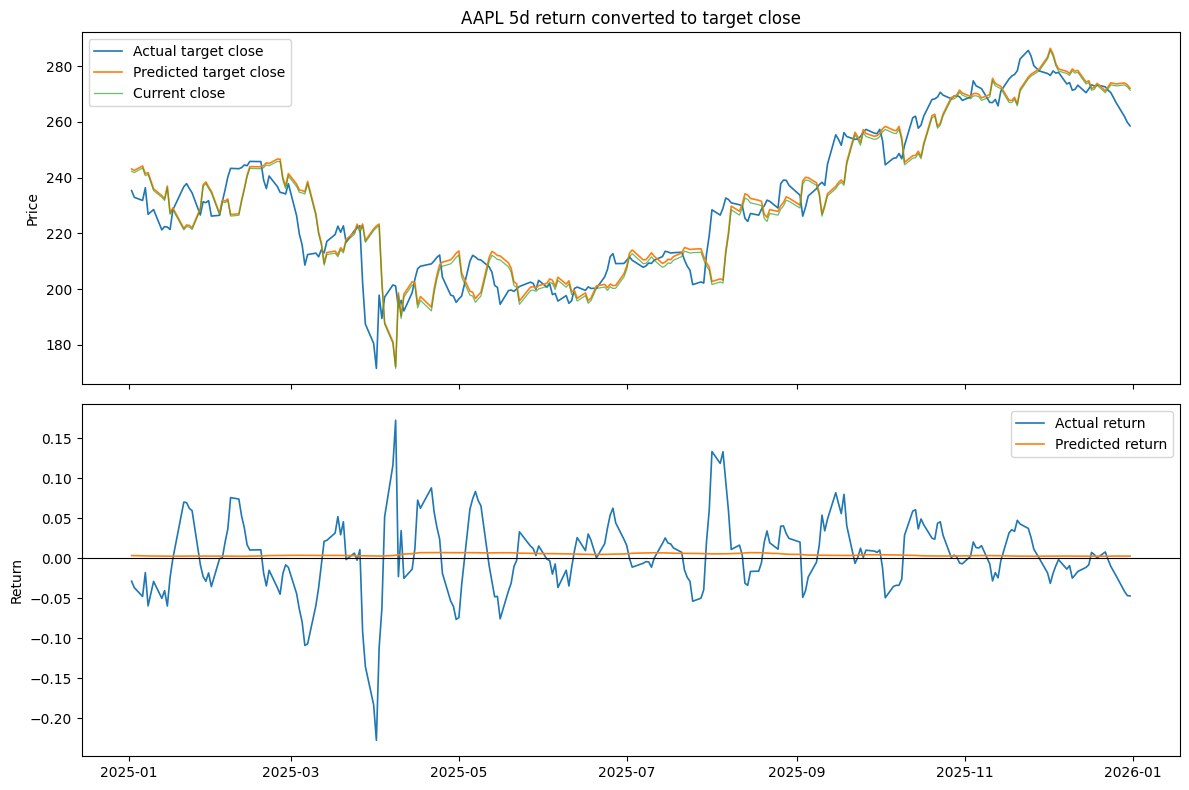

In [48]:
# Chart the single-ticker run before looking at sector-wide results.
if "artifact" in globals():
    plot_rows = artifact["metadata"].copy()
    plot_rows["actual_return"] = artifact["y_test"]
    plot_rows["predicted_return"] = artifact["y_pred"]
    plot_rows["current_close"] = artifact["current_close"]
    plot_rows["actual_close"] = artifact["target_close"]
    plot_rows["predicted_close"] = plot_rows["current_close"] * (
        1 + plot_rows["predicted_return"]
    )

    fig, axes = plt.subplots(2, 1, figsize=(12, 8), sharex=True)

    # The first chart shows whether the prediction follows the target close.
    axes[0].plot(
        plot_rows["prediction_date"],
        plot_rows["actual_close"],
        label="Actual target close",
        linewidth=1.2,
    )
    axes[0].plot(
        plot_rows["prediction_date"],
        plot_rows["predicted_close"],
        label="Predicted target close",
        linewidth=1.2,
    )
    axes[0].plot(
        plot_rows["prediction_date"],
        plot_rows["current_close"],
        label="Current close",
        linewidth=0.9,
        alpha=0.7,
    )
    axes[0].set_title(
        f"{SINGLE_TICKER} {FORECAST_HORIZON}d return converted to target close"
    )
    axes[0].set_ylabel("Price")
    axes[0].legend()

    # The second chart shows whether the model is mostly predicting returns near zero.
    axes[1].plot(
        plot_rows["prediction_date"],
        plot_rows["actual_return"],
        label="Actual return",
        linewidth=1.2,
    )
    axes[1].plot(
        plot_rows["prediction_date"],
        plot_rows["predicted_return"],
        label="Predicted return",
        linewidth=1.2,
    )
    axes[1].axhline(0, color="black", linewidth=0.8)
    axes[1].set_ylabel("Return")
    axes[1].legend()

    plt.tight_layout()
    plt.show()
else:
    print("Run the single ticker training cell first.")